## Loading dataset and importing Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_source/spotify_churn_dataset.csv')

## Checking the dataset for cleaning

In [3]:
df.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

In [4]:
df.isna().sum()

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

In [5]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [6]:
df.dtypes

user_id                    int64
gender                    object
age                        int64
country                   object
subscription_type         object
listening_time             int64
songs_played_per_day       int64
skip_rate                float64
device_type               object
ads_listened_per_week      int64
offline_listening          int64
is_churned                 int64
dtype: object

In [7]:
df.duplicated().sum()

0

### No null values and no duplicated values found in the dataset. 

# EDA Analysis

In [8]:
df.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

## Gender Map

In [9]:
df['gender'].value_counts(normalize=True)

Male      0.336375
Female    0.332375
Other     0.331250
Name: gender, dtype: float64

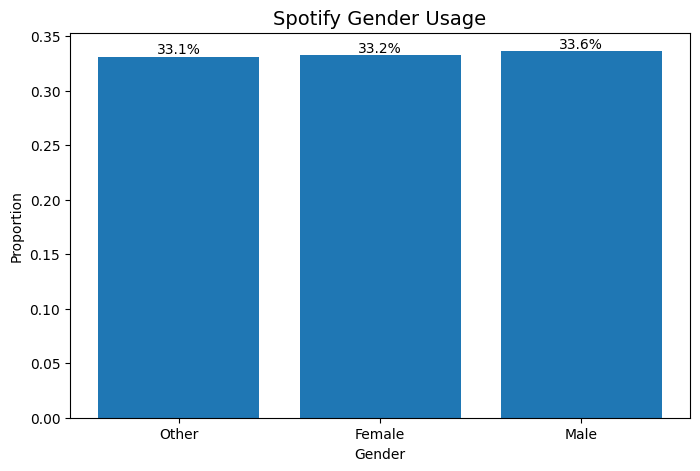

In [10]:
fig, ax = plt.subplots(figsize=(8,5))

gender_usage = df['gender'].value_counts(normalize=True).sort_values(ascending=True)

bars = ax.bar(gender_usage.index, gender_usage.values)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1%}',
            ha='center', va='bottom')

ax.set_title("Spotify Gender Usage", fontsize=14)
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion")

plt.show()

In [11]:
df.groupby('gender')['is_churned'].mean().sort_values(ascending=True)

gender
Male      0.251951
Other     0.261887
Female    0.262881
Name: is_churned, dtype: float64

In [12]:
df.groupby('gender')['is_churned'].agg(['count','mean'])

,count,mean
gender,,
Female,2659,0.262881
Male,2691,0.251951
Other,2650,0.261887


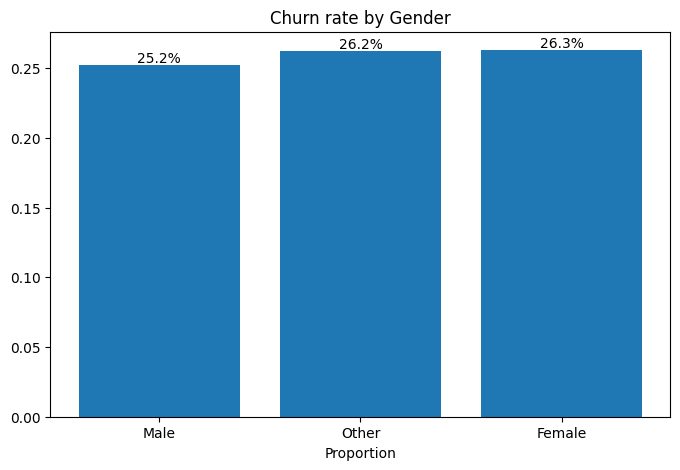

In [13]:
plt.style.use('default')
fig, ax = plt.subplots(figsize = (8,5))
gender_churn = df.groupby('gender')['is_churned'].mean().sort_values(ascending=True)
gender_churn_bars = ax.bar(gender_churn.index, gender_churn.values)

for bar in gender_churn_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1%}',
        ha='center',
        va='bottom'
    )

ax.set_title("Churn rate by Gender")
ax.set_xlabel("Proportion")

plt.show()

## The End

In [14]:
# churn rate helper — reuse this pattern for all charts
def churn_rate(df, col):
    return df.groupby(col)['is_churned'].mean() * 100

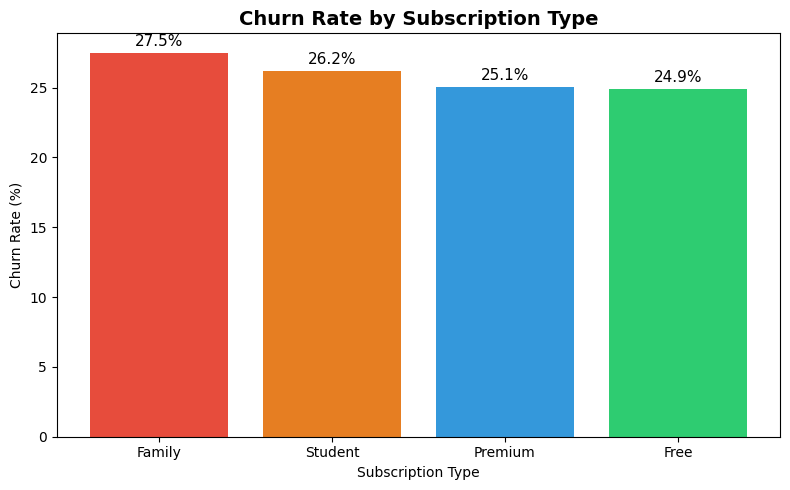

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

data = churn_rate(df, 'subscription_type').sort_values(ascending=False)
bars = ax.bar(data.index, data.values, color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'])

ax.set_title('Churn Rate by Subscription Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscription Type')
ax.set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/churn_by_subscription.png', dpi=150)
plt.show()

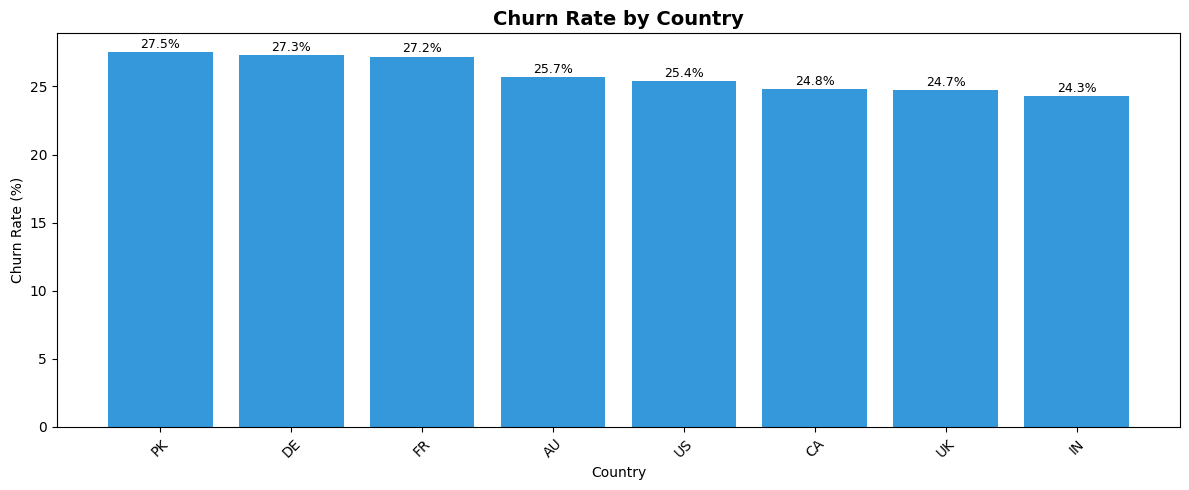

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

data = churn_rate(df, 'country').sort_values(ascending=False)
bars = ax.bar(data.index, data.values, color='#3498db')

ax.set_title('Churn Rate by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/churn_by_country.png', dpi=150)
plt.show()

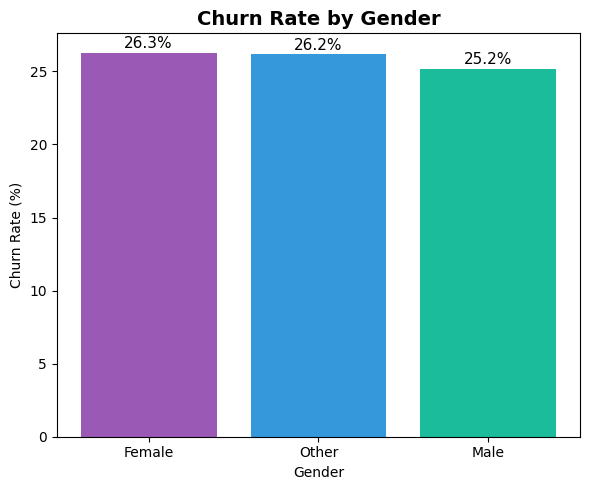

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))

data = churn_rate(df, 'gender').sort_values(ascending=False)
bars = ax.bar(data.index, data.values, color=['#9b59b6', '#3498db', '#1abc9c'])

ax.set_title('Churn Rate by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/churn_by_gender.png', dpi=150)
plt.show()

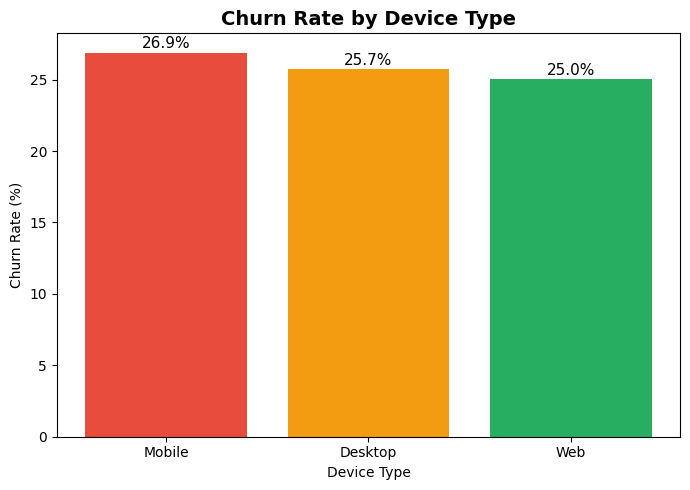

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

data = churn_rate(df, 'device_type').sort_values(ascending=False)
bars = ax.bar(data.index, data.values, color=['#e74c3c', '#f39c12', '#27ae60'])

ax.set_title('Churn Rate by Device Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Device Type')
ax.set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/churn_by_device.png', dpi=150)
plt.show()

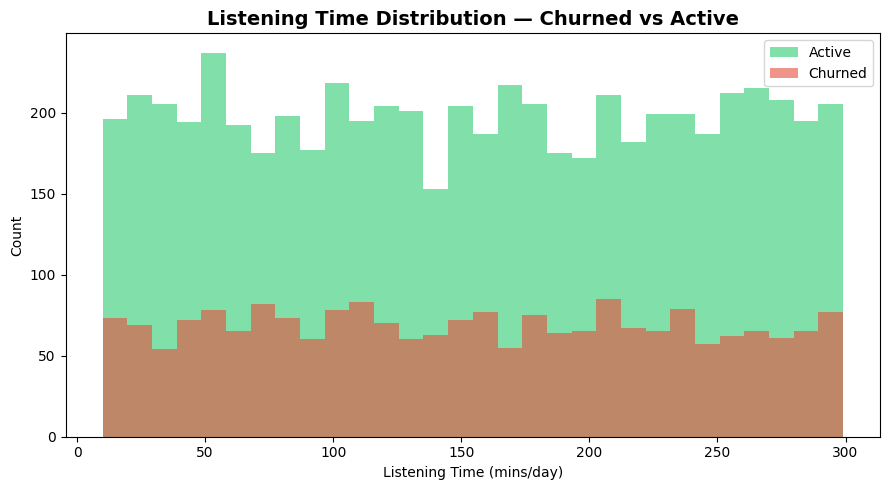

In [19]:
# 6. Listening time distribution — churned vs active
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df[df['is_churned'] == 0]['listening_time'], bins=30, alpha=0.6, color='#2ecc71', label='Active')
ax.hist(df[df['is_churned'] == 1]['listening_time'], bins=30, alpha=0.6, color='#e74c3c', label='Churned')

ax.set_title('Listening Time Distribution — Churned vs Active', fontsize=14, fontweight='bold')
ax.set_xlabel('Listening Time (mins/day)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/listening_time_dist.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2234/723473135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='songs_played_per_day',


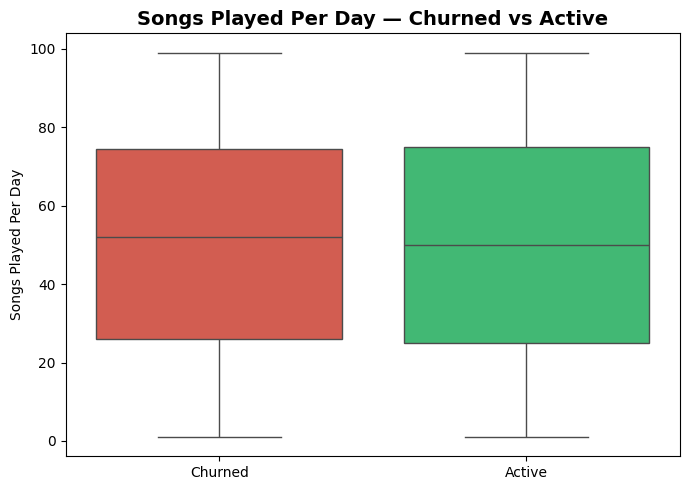

In [20]:
# 7. Songs played per day — churned vs active
fig, ax = plt.subplots(figsize=(7, 5))

df['churn_label'] = df['is_churned'].map({0: 'Active', 1: 'Churned'})
sns.boxplot(data=df, x='churn_label', y='songs_played_per_day',
            palette={'Active': '#2ecc71', 'Churned': '#e74c3c'}, ax=ax)

ax.set_title('Songs Played Per Day — Churned vs Active', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Songs Played Per Day')

plt.tight_layout()
plt.savefig('visualizations/songs_per_day_churn.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2234/2257151942.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='skip_rate',


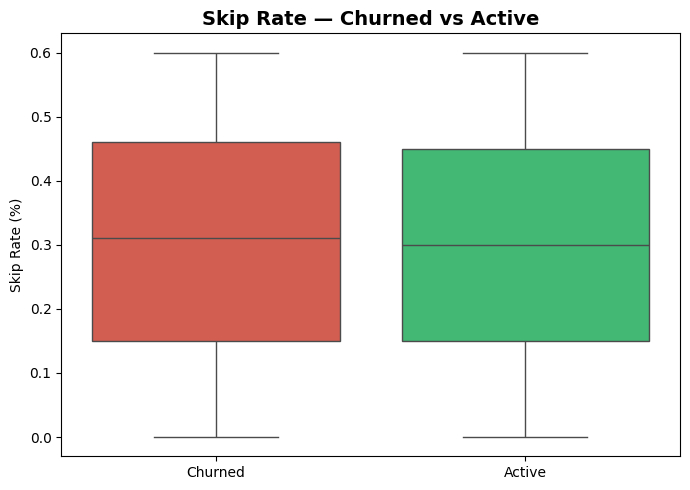

In [21]:
# 8. Skip rate — churned vs active
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='churn_label', y='skip_rate',
            palette={'Active': '#2ecc71', 'Churned': '#e74c3c'}, ax=ax)

ax.set_title('Skip Rate — Churned vs Active', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Skip Rate (%)')

plt.tight_layout()
plt.savefig('visualizations/skip_rate_churn.png', dpi=150)
plt.show()

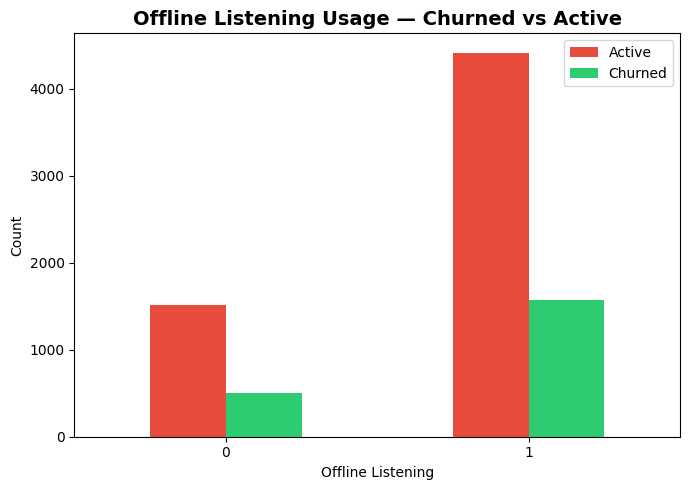

In [22]:
# 9. Offline listening — churned vs active
fig, ax = plt.subplots(figsize=(7, 5))

data = df.groupby(['offline_listening', 'churn_label']).size().unstack()
data.plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)

ax.set_title('Offline Listening Usage — Churned vs Active', fontsize=14, fontweight='bold')
ax.set_xlabel('Offline Listening')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='')

plt.tight_layout()
plt.savefig('visualizations/offline_listening_churn.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2234/1759455914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='ads_listened_per_week',


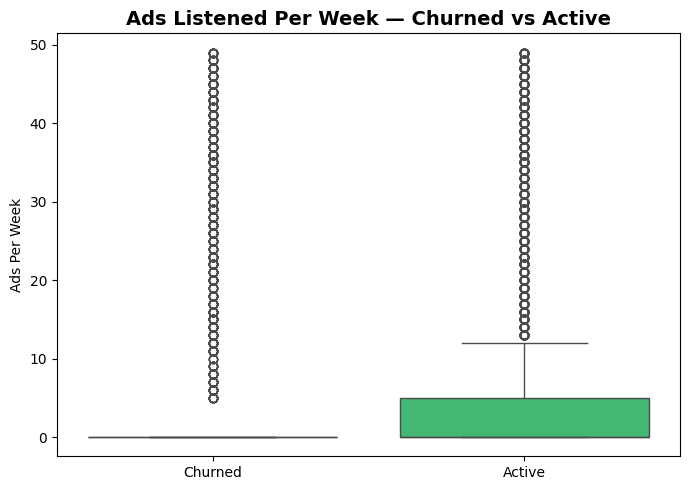

In [23]:
# 10. Ads per week — churned vs active
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='churn_label', y='ads_listened_per_week',
            palette={'Active': '#2ecc71', 'Churned': '#e74c3c'}, ax=ax)

ax.set_title('Ads Listened Per Week — Churned vs Active', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Ads Per Week')

plt.tight_layout()
plt.savefig('visualizations/ads_churn.png', dpi=150)
plt.show()

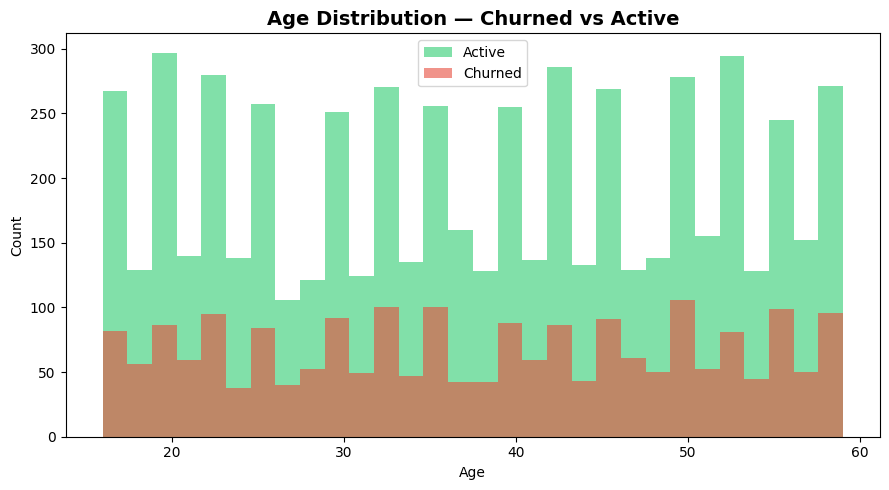

In [24]:
# 11. Age distribution — churned vs active
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df[df['is_churned'] == 0]['age'], bins=30, alpha=0.6, color='#2ecc71', label='Active')
ax.hist(df[df['is_churned'] == 1]['age'], bins=30, alpha=0.6, color='#e74c3c', label='Churned')

ax.set_title('Age Distribution — Churned vs Active', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/age_dist_churn.png', dpi=150)
plt.show()

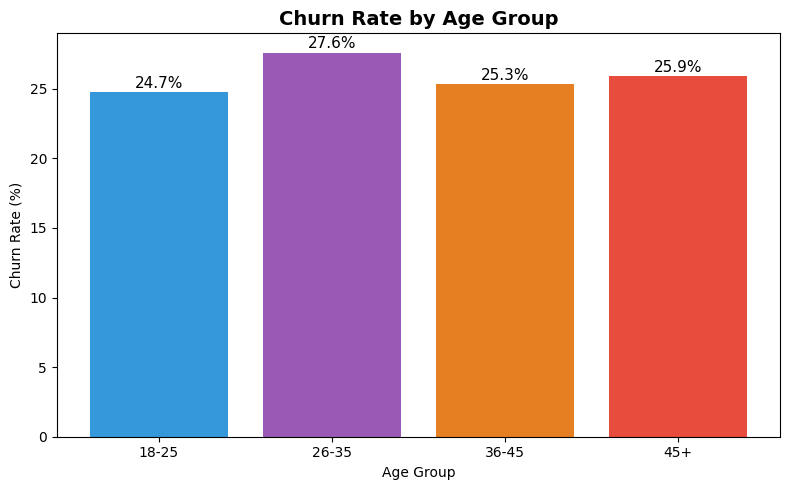

In [25]:
# 12. Churn rate by age group
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 25, 35, 45, 100],
                          labels=['18-25', '26-35', '36-45', '45+'])

fig, ax = plt.subplots(figsize=(8, 5))

data = df.groupby('age_group')['is_churned'].mean() * 100
bars = ax.bar(data.index, data.values, color=['#3498db', '#9b59b6', '#e67e22', '#e74c3c'])

ax.set_title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/churn_by_age_group.png', dpi=150)
plt.show()

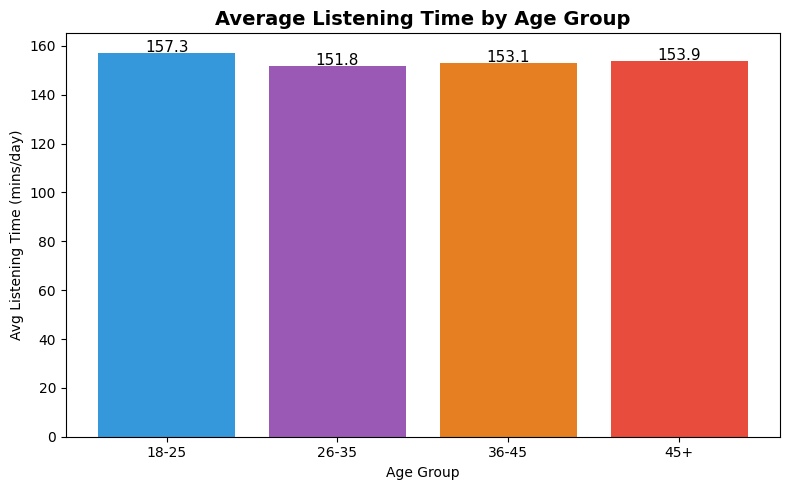

In [26]:
# 13. Average listening time by age group
fig, ax = plt.subplots(figsize=(8, 5))

data = df.groupby('age_group')['listening_time'].mean()
bars = ax.bar(data.index, data.values, color=['#3498db', '#9b59b6', '#e67e22', '#e74c3c'])

ax.set_title('Average Listening Time by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Avg Listening Time (mins/day)')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/listening_time_age_group.png', dpi=150)
plt.show()

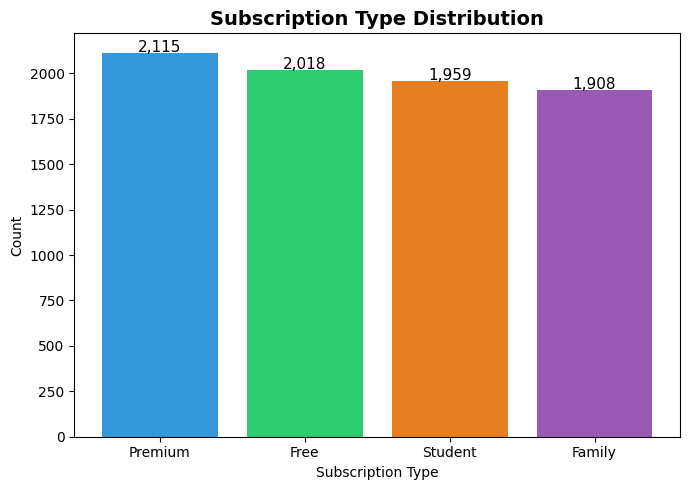

In [27]:
# 14. Subscription type distribution
fig, ax = plt.subplots(figsize=(7, 5))

data = df['subscription_type'].value_counts()
bars = ax.bar(data.index, data.values,
              color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'])

ax.set_title('Subscription Type Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscription Type')
ax.set_ylabel('Count')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/subscription_dist.png', dpi=150)
plt.show()

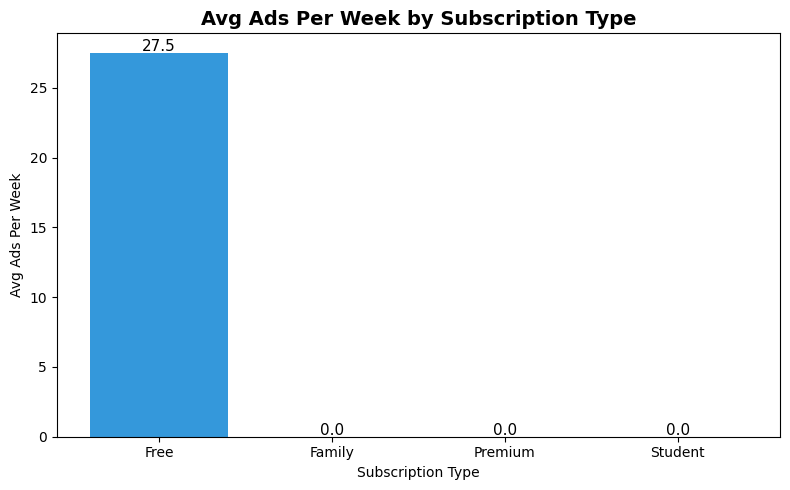

In [28]:
# 17. Ads per week by subscription type — data validation
fig, ax = plt.subplots(figsize=(8, 5))

data = df.groupby('subscription_type')['ads_listened_per_week'].mean().sort_values(ascending=False)
bars = ax.bar(data.index, data.values,
              color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'])

ax.set_title('Avg Ads Per Week by Subscription Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscription Type')
ax.set_ylabel('Avg Ads Per Week')

for bar, val in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('visualizations/ads_subscription.png', dpi=150)
plt.show()

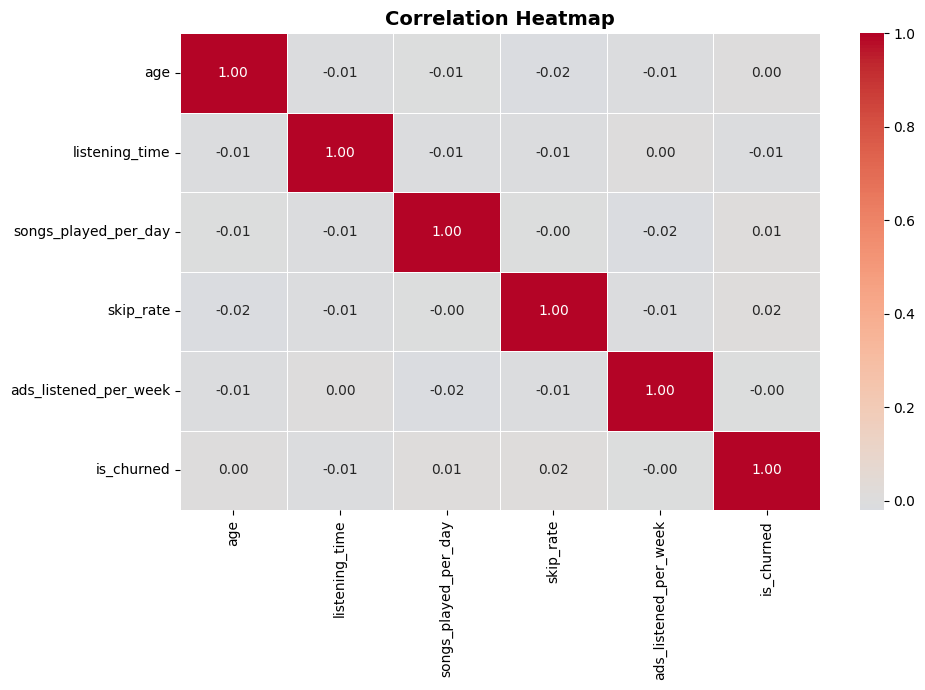

In [29]:
# 18. Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))

numeric_cols = ['age', 'listening_time', 'songs_played_per_day',
                'skip_rate', 'ads_listened_per_week', 'is_churned']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=150)
plt.show()

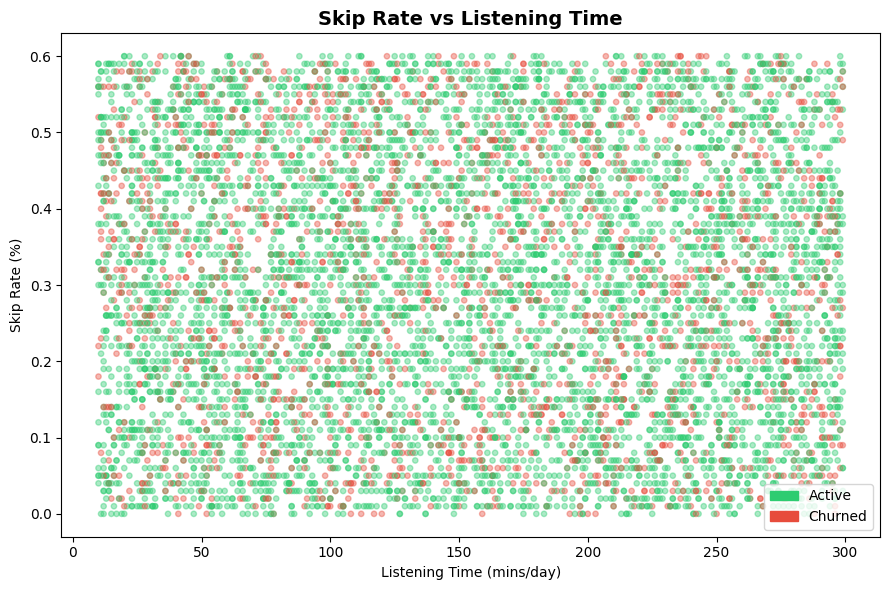

In [30]:
# 19. Skip rate vs listening time — colored by churn
fig, ax = plt.subplots(figsize=(9, 6))

colors = df['is_churned'].map({0: '#2ecc71', 1: '#e74c3c'})
ax.scatter(df['listening_time'], df['skip_rate'],
           c=colors, alpha=0.4, s=15)

ax.set_title('Skip Rate vs Listening Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Listening Time (mins/day)')
ax.set_ylabel('Skip Rate (%)')

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Active'),
          Patch(color='#e74c3c', label='Churned')]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('visualizations/skip_vs_listening_scatter.png', dpi=150)
plt.show()

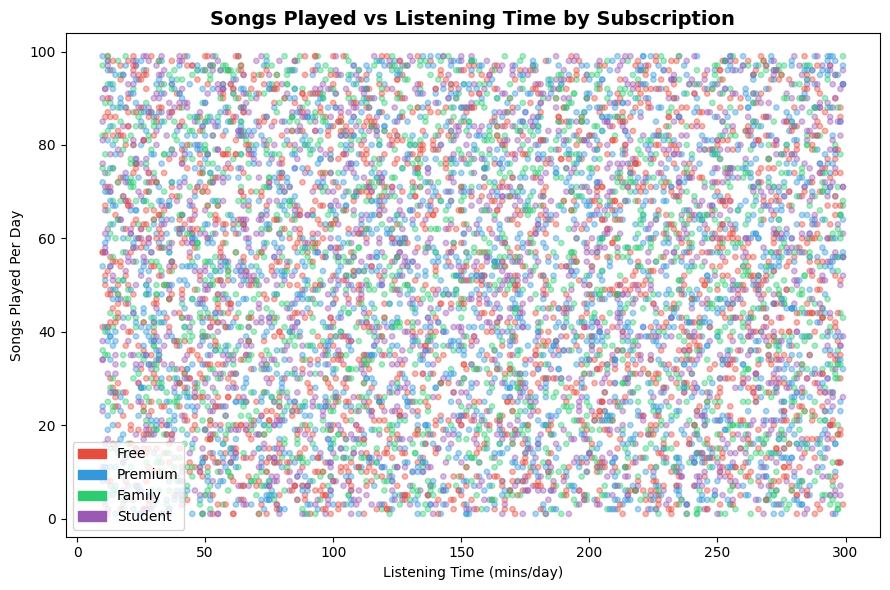

In [31]:
# 20. Songs played vs listening time — colored by subscription type
fig, ax = plt.subplots(figsize=(9, 6))

colors_map = {'Free': '#e74c3c', 'Premium': '#3498db',
              'Family': '#2ecc71', 'Student': '#9b59b6'}
colors = df['subscription_type'].map(colors_map)

ax.scatter(df['listening_time'], df['songs_played_per_day'],
           c=colors, alpha=0.4, s=15)

ax.set_title('Songs Played vs Listening Time by Subscription', fontsize=14, fontweight='bold')
ax.set_xlabel('Listening Time (mins/day)')
ax.set_ylabel('Songs Played Per Day')

from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('visualizations/songs_vs_listening_scatter.png', dpi=150)
plt.show()